# ppc-forecaster quickstart

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PPSwipUp/ppc-forecaster/blob/main/notebooks/quickstart.ipynb)

A forecaster that **keeps learning as data arrives**. In this notebook we:
1. forecast London's temperature 1 hour and 24 hours ahead from its own history,
2. see the honest score table (is it better than "no change"? better than a plain linear model?),
3. improve a **professional weather forecast** by letting it learn that forecast's local errors,
4. save the model and keep feeding it new data.

Every forecast is made *before* the value it predicts is seen, so all scores are out-of-sample.

In [1]:
%pip install -q -U ppc-forecaster matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import json, urllib.request
import pandas as pd
import matplotlib.pyplot as plt
from ppc.forecaster import Forecaster

def open_meteo(lat=51.51, lon=-0.13, start="2024-02-05", end="2026-09-01"):
    """hourly weather + the forecast a weather model issued ~1 day earlier (free, no API key)"""
    hv = "temperature_2m,relative_humidity_2m,pressure_msl,wind_speed_10m,cloud_cover,temperature_2m_previous_day1"
    url = (f"https://previous-runs-api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}"
           f"&start_date={start}&end_date={end}&hourly={hv}")
    df = pd.DataFrame(json.loads(urllib.request.urlopen(url, timeout=120).read())["hourly"])
    df["time"] = pd.to_datetime(df.time)
    # on row t: the professional forecast FOR t+24 (issued about a day before t+24)
    df["nwp24"] = df.temperature_2m_previous_day1.shift(-24)
    return df.drop(columns="temperature_2m_previous_day1")

df = open_meteo()
df.tail()

,time,temperature_2m,relative_humidity_2m,pressure_msl,wind_speed_10m,cloud_cover,nwp24
22555,2026-09-01 19:00:00,21.0,49,1019.4,11.9,100,NaN
22556,2026-09-01 20:00:00,19.9,57,1019.8,15.1,100,NaN
22557,2026-09-01 21:00:00,19.2,59,1020.2,13.7,100,NaN
22558,2026-09-01 22:00:00,18.8,61,1020.4,11.2,100,NaN
22559,2026-09-01 23:00:00,18.5,63,1020.1,10.4,100,NaN


## 1. Forecast from history
`fit_predict` streams every row through the models: forecast, then learn.

In [3]:
f = Forecaster(horizons=(1, 24), season=24)
pred = f.fit_predict(df, target="temperature_2m", time="time",
                     exog=["relative_humidity_2m", "pressure_msl", "wind_speed_10m", "cloud_cover"])
f.report()[["horizon", "model", "MAE_2nd_half", "skill_2nd_half", "coverage_2nd_half"]].round(3)

,horizon,model,MAE_2nd_half,skill_2nd_half,coverage_2nd_half
0,1,brain,0.301,0.491,NaN
1,1,linear,0.307,0.481,NaN
2,1,persistence,0.592,0.000,NaN
3,1,seasonal,2.059,-2.478,NaN
4,1,auto,0.301,0.492,0.804
5,24,brain,2.151,-0.044,NaN
6,24,linear,1.919,0.068,NaN
7,24,persistence,2.059,0.000,NaN
8,24,seasonal,2.059,0.000,NaN
9,24,auto,1.928,0.064,0.791


`skill` = 1 − error / error of "no change". **1 hour ahead** the brain is best. **24 hours ahead**,
from history alone, nothing does much better than "no change": weather a day out needs physics, which is next.

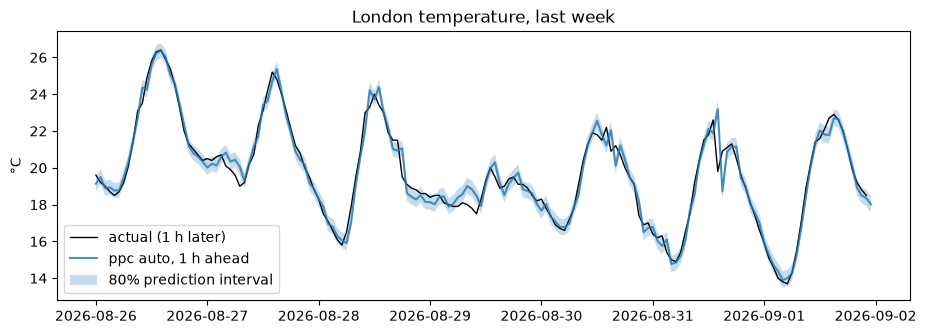

In [4]:
last = pred.iloc[-24 * 7:]
truth = df.temperature_2m.shift(-1).iloc[-24 * 7:]          # the value each 1-hour forecast was aiming at
plt.figure(figsize=(11, 3.5))
plt.plot(last.time, truth.values, label="actual (1 h later)", color="black", lw=1)
plt.plot(last.time, last.auto_h1, label="ppc auto, 1 h ahead", alpha=0.8)
plt.fill_between(last.time, last.auto_h1_lo, last.auto_h1_hi, alpha=0.25, label="80% prediction interval")
plt.legend(); plt.title("London temperature, last week"); plt.ylabel("°C"); plt.show()

The shaded band is an **80% prediction interval**, built from the forecaster's own recent errors. The report
above shows its real coverage (`coverage_2nd_half`): it should be close to 0.8. Several cycles work too, e.g.
`season=[24, 168]` for daily + weekly data such as energy use or shop footfall.

## 2. Improve a professional forecast
Give it the weather model's own 24-hour forecast as a `base`. It learns that forecast's local biases as it goes,
and `auto` switches between the raw forecast and the corrected one depending on which has been better lately.

In [5]:
g = Forecaster(horizons=(24,), season=24, base={24: "nwp24"})
g.fit_predict(df, target="temperature_2m", time="time",
              exog=["relative_humidity_2m", "pressure_msl", "wind_speed_10m", "cloud_cover"])
R = g.report().set_index("model")[["MAE_2nd_half", "skill_2nd_half"]].round(3)
R

,MAE_2nd_half,skill_2nd_half
model,,
brain,0.809,0.607
linear,0.785,0.619
persistence,2.059,0.000
seasonal,2.059,0.000
base,0.731,0.645
auto,0.720,0.650


In [6]:
print(f"professional forecast alone: {R.loc['base', 'MAE_2nd_half']:.3f} °C mean error")
print(f"ppc auto on top of it:        {R.loc['auto', 'MAE_2nd_half']:.3f} °C")

professional forecast alone: 0.731 °C mean error
ppc auto on top of it:        0.720 °C


For temperature the gain is small (the weather model is already very good). In our benchmark, 24-hour **wind**
forecasts improved by about 7–11%. Try `wind_speed_10m` yourself (fetch `wind_speed_10m_previous_day1` too).

## 3. Save it and keep learning
The saved model continues exactly where it stopped, with the same forecasts as one continuous run.

In [7]:
cut = len(df) - 24 * 14
h = Forecaster(horizons=(1,), season=24)
h.fit_predict(df.iloc[:cut], target="temperature_2m", time="time")
h.save("temp.ppc")

h = Forecaster.load("temp.ppc")
new = h.update(df.iloc[cut:])            # two new weeks arrive: forecast them, learn from them
new[["time", "y", "auto_h1"]].tail()

,time,y,auto_h1
331,2026-09-01 19:00:00,21.0,19.941309
332,2026-09-01 20:00:00,19.9,18.905083
333,2026-09-01 21:00:00,19.2,18.391672
334,2026-09-01 22:00:00,18.8,18.178844
335,2026-09-01 23:00:00,18.5,17.945234


## 4. Same thing from the command line

In [8]:
df.to_csv("london.csv", index=False)
# in a terminal this is just `ppc train ...`; `python -m ppc.cli` also works wherever pip put the package
import sys
!{sys.executable} -m ppc.cli train london.csv --target temperature_2m --time time --horizons 1,24 --season 24 --exog relative_humidity_2m,pressure_msl --save london.ppc

22560 rows, 2 exogenous columns, horizons [1, 24], raw scale, 2.1s



 horizon       model  MAE_all  RMSE_all  skill_all  MAE_2nd_half  skill_2nd_half  coverage_2nd_half  width_2nd_half
       1       brain   0.3272    0.4544     0.4426        0.3088          0.4784                                   
       1      linear   0.3245    0.4506     0.4472        0.3101          0.4762                                   
       1 persistence   0.5870    0.7785     0.0000        0.5920          0.0000                                   
       1    seasonal   2.0662    2.6893    -2.5199        2.0590         -2.4782                                   
       1        auto   0.3231    0.4500     0.4495        0.3076          0.4803             0.8030          0.9559
      24       brain   2.3413    2.9768    -0.1336        2.2419         -0.0886                                   
      24      linear   1.9333    2.4654     0.0639        1.9335          0.0611                                   
      24 persistence   2.0653    2.6887     0.0000        2.0594        

## Honest notes
- The brain wins at short horizons where inputs interact. At a day or more a linear model often wins, and `auto` handles that choice.
- On its own history it will not beat a physics-based weather model. Its value there is improving one.
- It is a forecaster, not a trading system. Tested on markets and sports betting, it found no edge that survives costs.